# Лабораторная работа #4
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

## Задание 1. Апроксимация функции двух переменных методом Гауссианы


Данные
Мои данные:
  Точка 0: x=0.89, y=0.97, z=0.41
  Точка 1: x=2.04, y=1.83, z=1.79
  Точка 2: x=2.82, y=3.05, z=4.28
  Точка 3: x=3.84, y=3.85, z=2.54
  Точка 4: x=4.97, y=4.85, z=0.50
Значения для инициализации модельных параметров (начальное приближение):
  Amplitude (A):     4.38
  Center (x0, y0):   (2.82, 3.05)
  Sigma_x:           0.71
  Sigma_y:           0.69
  Theta (rotation):  0.00 рад
  Offset:            0.00


Запускаем оптимизацию...

РЕЗУЛЬТАТЫ

A = 4.0144
x0 = 2.9798, y0 = 3.0440
sigma_x = 1.0896, sigma_y = 1.0860
theta = -0.0096 рад = -0.55°, offset = 0.3085

Финальная ошибка: 0.00000048

Проверка модели

Проверка:
Точка 0: z=0.41000, предсказание модели=0.41145, невязка=-0.00145
Точка 1: z=1.79000, предсказание модели=1.78991, невязка=0.00009
Точка 2: z=4.28000, предсказание модели=4.27985, невязка=0.00015
Точка 3: z=2.54000, предсказание модели=2.54037, невязка=-0.00037
Точка 4: z=0.50000, предсказание модели=0.49841, невязка=0.00159

Итоговая MSE = 0.000001

✅

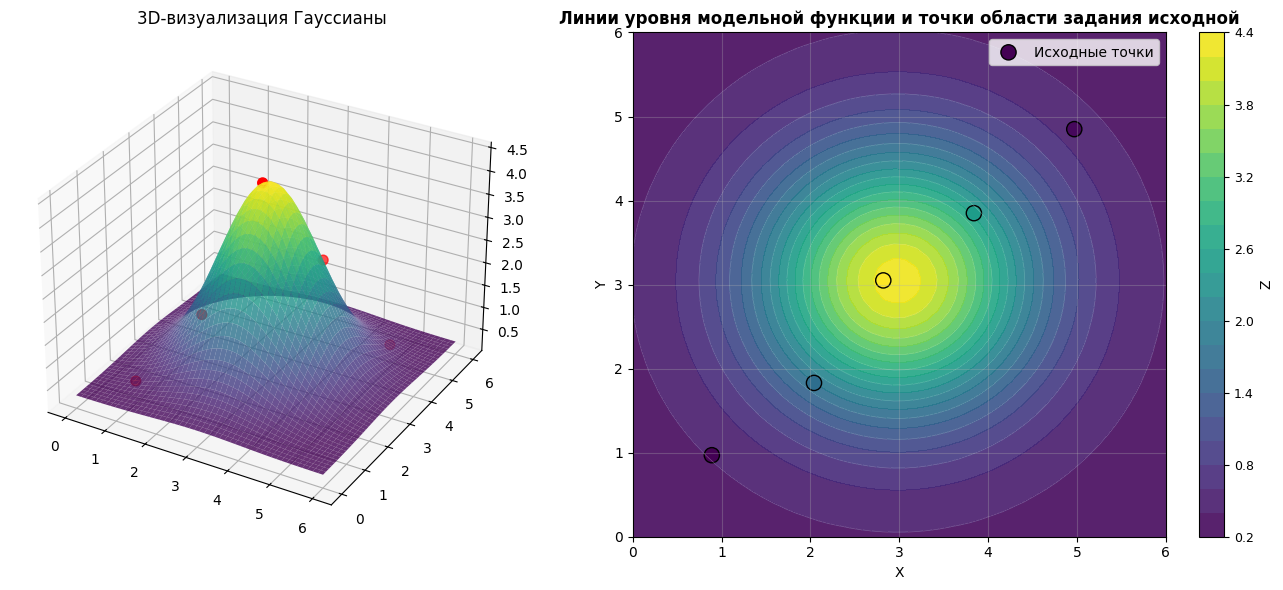

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==============================================================================
# Вариант 1
# ==============================================================================
data = np.array([
    [0.89, 0.97, 0.41],
    [2.04, 1.83, 1.79],
    [2.82, 3.05, 4.28],
    [3.84, 3.85, 2.54],
    [4.97, 4.85, 0.50]
])

# ==============================================================================
# ЗАДАНИЕ 1: Извлеките значения из data
# ==============================================================================
X = data[:, 0]  # первый столбец - признак X
Y = data[:, 1]  # второй столбец - признак Y
Z = data[:, 2]  # третий столбец - целевая переменная Z

print("\n" + "=" * 60)
print("Данные")
print("=" * 60)
print("Мои данные:")
for i in range(len(X)):
    print(f"  Точка {i}: x={X[i]:.2f}, y={Y[i]:.2f}, z={Z[i]:.2f}")


# ==============================================================================
# ЗАДАНИЕ 2: Функция Гаусса
# ==============================================================================
def gauss_2d(x, y, A, x0, y0, sigma_x, sigma_y, theta=0, offset=0):
    """
    2D функция Гаусса
    Формула: A * exp(-(x_new^2/(2*sigma_x^2) + y_new^2/(2*sigma_y^2))) + offset,
    x_new, y_new - координаты в канонической системе (получена из исходной сдвигом и поворотом,
    используя параметры x0, y0, theta)
    """
    if theta != 0:
        x_new = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
        y_new = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    else:
        x_new = x - x0
        y_new = y - y0
    exp_part = np.exp(-(x_new ** 2 / (2 * sigma_x ** 2) + y_new ** 2 / (2 * sigma_y ** 2)))
    result = A * exp_part + offset

    return result


# ==============================================================================
# ЗАДАНИЕ 3: Функция потерь (loss-функция, функция ошибки)
# ==============================================================================
def loss_function(model_params):
    """
    Вычисляем MSE для реальных и модельных значений на объектах.
    """
    A, x0, y0, sigma_x, sigma_y, theta, offset = model_params

    if sigma_x <= 0 or sigma_y <= 0 or A <= 0:
        return 1e10

    predictions = []
    for i in range(len(X)):
        pred = gauss_2d(X[i], Y[i], A, x0, y0, sigma_x, sigma_y, theta, offset)
        predictions.append(pred)

    errors = Z - predictions
    mse = 0.5 * np.mean(errors ** 2)
    return mse


# ==============================================================================
# ЗАДАНИЕ 4: Начальное приближение
# ==============================================================================
max_idx = np.argmax(Z)  # индекс, соотв. максимуму Z
A_start = Z[max_idx] + 0.1  # значение максимума Z с произвольной корректировкой
x0_start = X[max_idx]  # значение Х, соотв. max_idx
y0_start = Y[max_idx]  # значение Y, соотв. max_idx
sigma_x_start = np.std(X) * 0.5
sigma_y_start = np.std(Y) * 0.5
offset_start = 0.0
theta_start = 0.0

params_start = [A_start, x0_start, y0_start, sigma_x_start, sigma_y_start, theta_start, offset_start]

print(f"Значения для инициализации модельных параметров (начальное приближение):")
print(f"  Amplitude (A):     {A_start:.2f}")
print(f"  Center (x0, y0):   ({x0_start:.2f}, {y0_start:.2f})")
print(f"  Sigma_x:           {sigma_x_start:.2f}")
print(f"  Sigma_y:           {sigma_y_start:.2f}")
print(f"  Theta (rotation):  0.00 рад")
print(f"  Offset:            0.00")
print()

# ==============================================================================
# ЗАДАНИЕ 5: Границы и оптимизация (не менять)
# ==============================================================================
bounds = [
    (0.1, 10.0), (0.0, 6.0), (0.0, 6.0),
    (0.1, 5.0), (0.1, 5.0), (-np.pi / 4, np.pi / 4), (-1.0, 1.0)
]

print("\nЗапускаем оптимизацию...")
result = minimize(loss_function, params_start, method='L-BFGS-B', bounds=bounds)

# ==============================================================================
# РЕЗУЛЬТАТЫ
# ==============================================================================
A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt = result.x

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ")
print("=" * 50)
print(f"\nA = {A_opt:.4f}")
print(f"x0 = {x0_opt:.4f}, y0 = {y0_opt:.4f}")
print(f"sigma_x = {sigma_x_opt:.4f}, sigma_y = {sigma_y_opt:.4f}")
print(f"theta = {theta_opt:.4f} рад = {np.degrees(theta_opt):.2f}°, offset = {offset_opt:.4f}")
print(f"\nФинальная ошибка: {result.fun:.8f}")

# ==============================================================================
# ЗАДАНИЕ 6: Проверка
# ==============================================================================
predictions = []
for i in range(len(X)):
    pred = gauss_2d(X[i], Y[i], A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt)
    predictions.append(pred)

print("\n" + "=" * 60)
print("Проверка модели")
print("=" * 60)
print("\nПроверка:")

for i in range(len(X)):
    print(f"Точка {i}: z={Z[i]:.5f}, предсказание модели={predictions[i]:.5f}, невязка={Z[i] - predictions[i]:.5f}")

# Вычисление итоговой MSE
final_mse = np.mean((Z - predictions) ** 2)
print(f"\nИтоговая MSE = {final_mse:.6f}")

# ==============================================================================
# ЗАДАНИЕ 7: Визуализация
# ==============================================================================
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid = np.zeros((50, 50))
for i in range(50):
    for j in range(50):
        Z_grid[i, j] = gauss_2d(X_grid[i, j], Y_grid[i, j], A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt,
                                offset_opt)

# Графики
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.8)
ax1.scatter(X, Y, Z, c='red', s=50)
ax1.set_title('3D-визуализация Гауссианы')

ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.9)
scatter = ax2.scatter(X, Y, c=Z, s=120, edgecolors='black', cmap='viridis', label='Исходные точки')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_title('Линии уровня модельной функции и точки области задания исходной', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
cbar = plt.colorbar(contour, ax=ax2, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
print("\n✅ Готово! Получилась двумерная гауссиана - аппроксимация для z(x,y)!")
plt.show()
